<a href="https://colab.research.google.com/github/sparshtelang/Sparsh_23FE10CSE00433/blob/main/Test1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import load_breast_cancer

# Load the dataset
bc = load_breast_cancer()

In [2]:
# Display the feature names and target names
print("Feature names:", bc.feature_names)
print("Target names:", bc.target_names)

Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Target names: ['malignant' 'benign']


The `data` attribute contains the feature matrix, and the `target` attribute contains the target vector. Let's see their shapes.

In [3]:
print("Shape of feature matrix (data):")
print(bc.data.shape)
print("\nShape of target vector (target):")
print(bc.target.shape)

Shape of feature matrix (data):
(569, 30)

Shape of target vector (target):
(569,)


## Data Preprocessing

First, we'll separate the features (X) from the target variable (y).

In [4]:
X = bc.data
y = bc.target

print("Shape of X (features):")
print(X.shape)
print("\nShape of y (target):")
print(y.shape)

Shape of X (features):
(569, 30)

Shape of y (target):
(569,)


Next, we'll split the data into training and testing sets to evaluate our model's performance on unseen data. We'll use a standard split ratio of 80% for training and 20% for testing.

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (455, 30)
Shape of X_test: (114, 30)
Shape of y_train: (455,)
Shape of y_test: (114,)


Finally, we'll scale the features using `StandardScaler`. This is important for many machine learning algorithms, as it helps prevent features with larger values from dominating the learning process.

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Mean of X_train_scaled after scaling:", X_train_scaled.mean(axis=0).round(2))
print("Standard deviation of X_train_scaled after scaling:", X_train_scaled.std(axis=0).round(2))

Mean of X_train_scaled after scaling: [-0. -0. -0. -0. -0.  0.  0.  0. -0. -0.  0. -0.  0.  0. -0. -0.  0.  0.
 -0.  0.  0. -0. -0. -0.  0. -0. -0.  0.  0. -0.]
Standard deviation of X_train_scaled after scaling: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


## Data Visualization

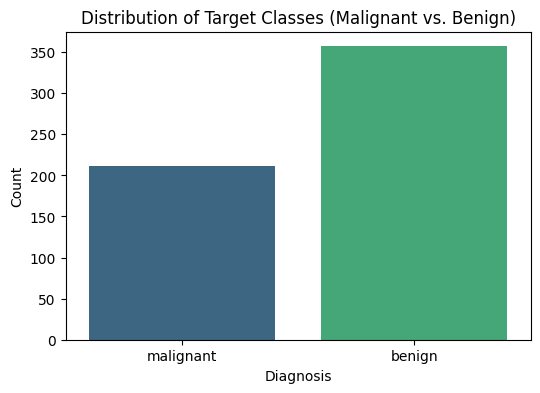

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert target to a DataFrame for easier plotting with seaborn
target_df = pd.DataFrame(bc.target, columns=['target'])
target_df['target_names'] = target_df['target'].map({0: 'malignant', 1: 'benign'})

plt.figure(figsize=(6, 4))
sns.countplot(x='target_names', data=target_df, palette='viridis', hue='target_names', legend=False)
plt.title('Distribution of Target Classes (Malignant vs. Benign)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

This count plot shows the number of malignant (class 0) and benign (class 1) cases in the dataset. It helps us understand if the dataset is balanced or imbalanced, which can be important for model evaluation.

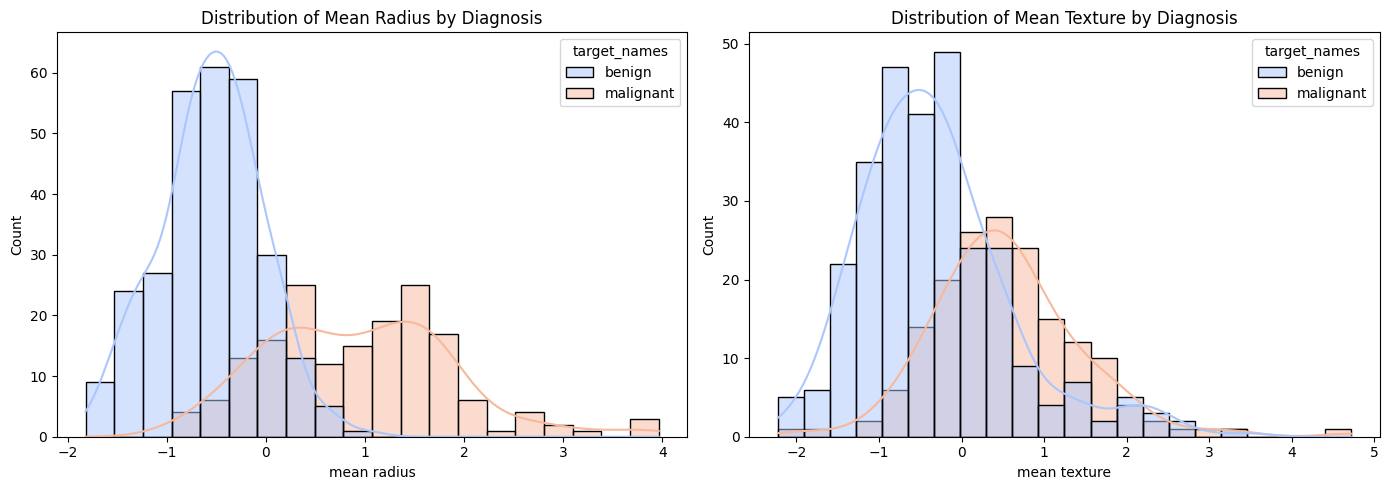

In [10]:
# Let's visualize the distribution of a few important features from the scaled training data
# We'll pick 'mean radius' and 'mean texture' as examples

# Create a DataFrame for scaled features to easily plot with seaborn
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=bc.feature_names)
X_train_scaled_df['target'] = y_train
X_train_scaled_df['target_names'] = X_train_scaled_df['target'].map({0: 'malignant', 1: 'benign'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=X_train_scaled_df, x='mean radius', hue='target_names', kde=True, ax=axes[0], palette='coolwarm')
axes[0].set_title('Distribution of Mean Radius by Diagnosis')

sns.histplot(data=X_train_scaled_df, x='mean texture', hue='target_names', kde=True, ax=axes[1], palette='coolwarm')
axes[1].set_title('Distribution of Mean Texture by Diagnosis')

plt.tight_layout()
plt.show()

## Model Training and Evaluation

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred = model.predict(X_test_scaled)

print("Model training complete. Now evaluating performance...")

Model training complete. Now evaluating performance...


Now, let's evaluate the model's performance using several common metrics.

Accuracy: 0.9737
Precision: 0.9722
Recall: 0.9859
F1-Score: 0.9790


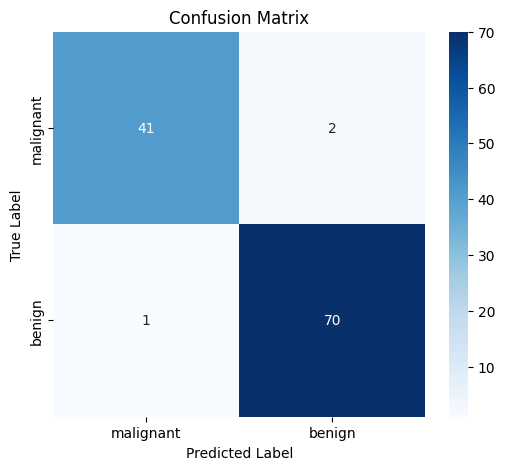


Confusion Matrix (True vs. Predicted):
 [[41  2]
 [ 1 70]]


In [12]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=bc.target_names, yticklabels=bc.target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nConfusion Matrix (True vs. Predicted):\n", cm)

These histograms illustrate the distributions of 'mean radius' and 'mean texture' features, separated by the 'malignant' and 'benign' diagnoses. This can reveal how these features differ between the two classes, providing insights into their predictive power.